In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Training Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, losses, optimizers
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2
import os

AUTOTUNE = tf.data.AUTOTUNE


## **1. Đọc dữ liệu và tiền xử lý ảnh vân tay**

### **1.1 Đường dẫn dữ liệu**

* **`merged_dir`**: là đường dẫn đến thư mục chứa toàn bộ ảnh dấu vân tay sau khi đã hợp nhất từ các nguồn khác nhau. Đây là nơi mô hình sẽ tìm kiếm ảnh đầu vào.
* **`csv_path`**: là đường dẫn đến file CSV chứa danh sách các cặp ảnh dùng để huấn luyện mô hình. Mỗi dòng trong file này gồm tên hai ảnh và một nhãn (label) cho biết hai ảnh đó có thuộc cùng một ngón tay hay không.


In [ ]:
# Đường dẫn dữ liệu
merged_dir = '/content/drive/MyDrive/Recognition/dataset_finger/Fingerprint'
csv_path = '/content/drive/MyDrive/Recognition/dataset_finger/pairs_train.csv'

### **1.2 Đọc dữ liệu từ file CSV**

* Sử dụng thư viện **Pandas** để đọc file `pairs.csv` vào dạng bảng dữ liệu (DataFrame).
* Mỗi dòng trong bảng tương ứng với một cặp ảnh:

  * **file1**: tên ảnh thứ nhất
  * **file2**: tên ảnh thứ hai
  * **label**: nhãn 0 hoặc 1, trong đó:

    * `1` nếu hai ảnh thuộc cùng một ngón tay (cặp positive)
    * `0` nếu hai ảnh thuộc ngón tay khác nhau (cặp negative)

In [ ]:
# Đọc CSV
pairs_df = pd.read_csv(csv_path)

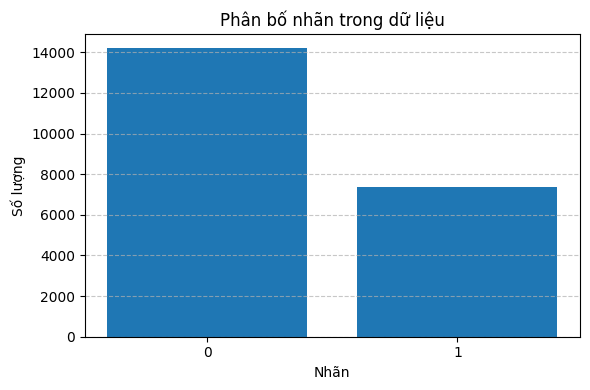

In [ ]:
# Đếm số lượng nhãn
label_counts = pairs_df['label'].value_counts().sort_index()

# Vẽ biểu đồ
plt.figure(figsize=(6, 4))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.title('Phân bố nhãn trong dữ liệu')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **1.3 Định nghĩa kích thước ảnh chuẩn**

* Kích thước ảnh được chuẩn hóa về **100 x 100 pixel**.
* Việc chuẩn hóa kích thước giúp đảm bảo tính đồng nhất giữa các ảnh đầu vào, giảm độ phức tạp tính toán và giúp mô hình học hiệu quả hơn.

In [ ]:
# Resize ảnh
IMG_SIZE = 100  # bạn có thể đổi tùy độ phân giải ảnh gốc

### **1.4 Hàm đọc và tiền xử lý ảnh**

Hàm thực hiện các bước xử lý ảnh đầu vào như sau:

* **Tạo đường dẫn đầy đủ**: kết hợp tên file ảnh với đường dẫn thư mục để xác định đúng vị trí ảnh cần đọc.
* **Đọc ảnh ở chế độ đen trắng (grayscale)**: chỉ lấy kênh độ sáng, giúp giảm dung lượng và thời gian xử lý mà vẫn giữ lại thông tin đặc trưng của vân tay.
* **Resize ảnh**: thu phóng ảnh về kích thước chuẩn 100x100 pixel, nhằm đảm bảo đồng nhất trong tập dữ liệu.
* **Chuẩn hóa dữ liệu ảnh**: chuyển giá trị pixel từ khoảng `[0, 255]` về `[0, 1]`. Điều này giúp mô hình học máy hoạt động ổn định hơn, tránh bị ảnh hưởng bởi giá trị lớn nhỏ của pixel.

In [ ]:
# Hàm đọc và tiền xử lý ảnh
def load_image(filename):
    path = os.path.join(merged_dir, filename)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype("float32") / 255.0
    return img


## **2. Chuẩn bị dữ liệu huấn luyện**
Đây là bước tiền xử lý quan trọng giúp chuyển dữ liệu từ định dạng file ảnh và CSV sang một định dạng chuẩn TensorFlow, phù hợp để đưa vào mô hình học sâu (deep learning). Việc xáo trộn, chia batch và chia train/validation đảm bảo mô hình được huấn luyện một cách chính xác và hiệu quả.

### **2.1 Chuyển ảnh thành mảng Numpy**

* Từ file CSV chứa tên các cặp ảnh, ta lần lượt đọc từng ảnh bằng hàm `load_image` đã định nghĩa trước đó.
* Mỗi ảnh được chuyển thành một mảng Numpy (NumPy array), tạo thành hai danh sách ảnh tương ứng với cột `img1` và `img2`.
* **`labels`** là cột nhãn tương ứng của mỗi cặp ảnh, được chuyển thành mảng số thực (`float32`) để mô hình TensorFlow có thể xử lý.

In [ ]:
from concurrent.futures import ThreadPoolExecutor
import numpy as np

def load_img_from_row(row):
    return load_image(row['img1']), load_image(row['img2'])

with ThreadPoolExecutor() as executor:
    results = list(executor.map(load_img_from_row, [row for _, row in pairs_df.iterrows()]))

# Tách riêng img1, img2
img1 = np.array([r[0] for r in results])
img2 = np.array([r[1] for r in results])
labels = pairs_df['label'].values.astype('float32')


### **2.2 Thêm chiều kênh màu (channel)**

* Ảnh vân tay sau khi đọc là ảnh đen trắng (grayscale), nên chỉ có 2 chiều: **(height, width)**.
* Tuy nhiên, mô hình học sâu (deep learning) thường yêu cầu ảnh có 3 chiều: **(height, width, channels)**.
* Vì vậy, ta thêm một chiều thứ 3 với giá trị là `1` để biểu thị đây là ảnh grayscale với 1 kênh màu. Kết quả là ảnh có shape **(100, 100, 1)**.

In [ ]:
# Thêm kênh (1) vì ảnh grayscale
img1 = img1[..., np.newaxis]
img2 = img2[..., np.newaxis]

### **2.3 Chia dữ liệu thành tập huấn luyện và validation**

- Tập dữ liệu được chia bằng slicing NumPy theo tỉ lệ **85% huấn luyện và 15% kiểm định**.

- img1 và img2 là hai tập ảnh tương ứng với từng cặp vân tay.

- labels là nhãn nhị phân: 1 nếu cùng ngón tay, 0 nếu khác ngón tay.


In [ ]:
train_size = int(0.85 * len(labels))
img1_train, img1_val = img1[:train_size], img1[train_size:]
img2_train, img2_val = img2[:train_size], img2[train_size:]
labels_train, labels_val = labels[:train_size], labels[train_size:]


### **2.4 Tạo tập huấn luyện và kiểm định với `tf.data.Dataset`**

* Sử dụng `tf.data.Dataset` để biến các mảng NumPy đã chia thành **pipeline dữ liệu đầu vào** cho mô hình.

* **`train_ds`**: gồm các cặp ảnh và nhãn phục vụ cho huấn luyện. Dữ liệu được:

  * `shuffle(2048)` để tránh mô hình học theo thứ tự cố định.
  * `batch(32)` chia thành mini-batch giúp tăng hiệu suất tính toán.
  * `prefetch(AUTOTUNE)` để song song hóa việc tải dữ liệu và huấn luyện mô hình, tăng tốc độ training.

* **`val_ds`**: là tập dữ liệu validation không cần shuffle, cũng được batch và prefetch để đảm bảo hiệu suất.

Tối ưu hiệu quả huấn luyện bằng cách chuẩn hóa đầu vào dưới dạng pipeline TensorFlow, đảm bảo mô hình nhận dữ liệu đúng định dạng, nhanh và ổn định.


In [ ]:
# Tạo dataset từ phần đã chia
train_ds = tf.data.Dataset.from_tensor_slices(((img1_train, img2_train), labels_train))
train_ds = train_ds.shuffle(2048).batch(32).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(((img1_val, img2_val), labels_val))
val_ds = val_ds.batch(32).prefetch(AUTOTUNE)


## **3. Xây dựng mô hình Siamese với CNN cơ bản**
Mô hình Siamese sử dụng kiến trúc CNN để học đặc trưng của ảnh vân tay, sau đó đo khoảng cách giữa hai vector đặc trưng để dự đoán xem hai ảnh có thuộc cùng một ngón tay hay không. Đây là phương pháp hiệu quả cho bài toán xác thực (verification) dấu vân tay.



### **3.1 Hàm xây dựng mạng CNN cơ bản (`build_base_cnn`)**

Hàm `build_base_cnn` xây dựng một mô hình mạng nơ-ron tích chập (Convolutional Neural Network – CNN) cơ bản, được sử dụng làm bộ trích xuất đặc trưng (feature extractor) cho từng ảnh đầu vào trong mạng Siamese. Kiến trúc mạng gồm:


* **Input Layer**: nhận ảnh đầu vào với kích thước đã chuẩn hóa (100x100x1).
* **3 lớp Convolutional**:

  * Lớp 1: 32 bộ lọc kích thước 3x3, dùng hàm kích hoạt ReLU. Giúp phát hiện các đặc trưng cục bộ ban đầu như cạnh, đường cong, ...
  * Lớp 2: 64 bộ lọc 3x3, ReLU. Với số lượng filter tăng dần, nhằm học các đặc trưng phức tạp hơn.
  * Lớp 3: 128 bộ lọc 3x3, ReLU. Trích xuất đặc trưng cấp cao – mô hình hóa cấu trúc tổng thể, giúp phân biệt các vân tay.
* **Lớp MaxPooling** sau mỗi lớp convolution: giúp giảm kích thước không gian, giúp mô hình giảm độ phức tạp và giữ lại đặc trưng quan trọng.
* **GlobalAveragePooling2D**: thay vì flatten toàn bộ feature map (dễ dẫn đến overfitting), lớp này tính giá trị trung bình toàn cục cho mỗi feature map, giúp mô hình khái quát tốt hơn và giảm số lượng tham số đáng kể.
* **Dense Layer (128 units, ReLU)**: Biến đầu ra thành một vector đặc trưng có kích thước 128 chiều. Đây chính là **embedding vector** đại diện cho ảnh đầu vào, được dùng để so sánh với embedding của ảnh còn lại.



**Kết quả**: mỗi ảnh đầu vào sẽ được ánh xạ thành một vector đặc trưng 128 chiều.

In [ ]:
# CNN cơ bản
def build_base_cnn(input_shape):
    model = models.Sequential([
        layers.Input(input_shape),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu')
    ])
    return model

### **3.2 Hàm tính khoảng cách L1 (`l1_distance`)**

* Hàm `l1_distance(vects)` nhận hai vector đặc trưng đầu ra từ hai ảnh (gọi là `x` và `y`).
* Trả về giá trị **|x - y|**, tức là hiệu tuyệt đối của từng thành phần giữa hai vector.
* Đây là cách đo khoảng cách L1 (Manhattan distance), thường dùng trong các mô hình so sánh.

In [ ]:
# Hàm khoảng cách L1
def l1_distance(vects):
    x, y = vects
    return tf.abs(x - y)

### **3.3 Xây dựng mô hình Siamese Network**

Mô hình **Siamese Network** được thiết kế để so sánh hai ảnh đầu vào và xác định xem chúng có thuộc cùng một đối tượng (cùng ngón tay) hay không.

**Cấu trúc logic**:

* **Hai ảnh đầu vào** (`input_a`, `input_b`) có cùng kích thước được định nghĩa bởi `input_shape = (IMG_SIZE, IMG_SIZE, 1)`, tức ảnh grayscale 1 kênh.
* Cả hai ảnh được đưa vào **cùng một mạng nơ-ron tích chập cơ sở** `base_cnn`, sử dụng lại trọng số (shared weights), để rút trích ra hai vector đặc trưng: `feat_a` và `feat_b`.
* Việc chia mô hình thành hai nhánh giúp hệ thống học được **khoảng cách đặc trưng** giữa hai ảnh hơn là nội dung cụ thể của từng ảnh.

**Ý nghĩa kỹ thuật**:

* `base_cnn` là một mô hình Convolutional Neural Network (CNN) cơ bản được định nghĩa riêng, có nhiệm vụ trích xuất đặc trưng từ ảnh đầu vào.
* `feat_a = base_cnn(input_a)` và `feat_b = base_cnn(input_b)`: đảm bảo rằng cả hai ảnh được mã hóa theo cùng một cách để có thể so sánh một cách công bằng.

Đây là bước rút trích đặc trưng từ hai ảnh.



In [ ]:
# Xây dựng mô hình
input_shape = (IMG_SIZE, IMG_SIZE, 1)
base_cnn = build_base_cnn(input_shape)

input_a = layers.Input(shape=input_shape)
input_b = layers.Input(shape=input_shape)

feat_a = base_cnn(input_a)
feat_b = base_cnn(input_b)

### **3.4 Tầng đầu ra**

Sau khi tính khoảng cách L1 giữa hai vector đặc trưng, kết quả được đưa vào một **tầng Dense (fully connected)** với **duy nhất một node** và sử dụng **hàm kích hoạt tuyến tính (`activation='linear'`)**. Điều này đồng nghĩa với việc đầu ra của mô hình là **logits** – tức giá trị thực chưa qua chuẩn hóa thành xác suất.

Việc **không sử dụng hàm sigmoid tại tầng đầu ra** là một lựa chọn thiết kế có chủ đích. Thay vào đó, hàm sigmoid sẽ được **tích hợp trực tiếp bên trong hàm loss** (`BinaryCrossentropy(from_logits=True)`) trong quá trình huấn luyện. Cách làm này giúp mô hình đạt **tính ổn định số học cao hơn**, đặc biệt khi logits có giá trị lớn hoặc nhỏ cực đoan.

Sau khi áp dụng sigmoid (trong lúc đánh giá hoặc inference), đầu ra sẽ là một xác suất thể hiện **mức độ tương đồng giữa hai ảnh vân tay**:

* **Xác suất gần 1** → hai ảnh có khả năng **cùng ngón tay** rất cao.
* **Xác suất gần 0** → hai ảnh có khả năng **khác ngón tay**.





In [ ]:
# Khoảng cách + tầng đầu ra
merged = layers.Lambda(l1_distance)([feat_a, feat_b])
output = layers.Dense(1, activation='linear')(merged)

### **3.5 Biên dịch mô hình (Compile)**

Quá trình biên dịch mô hình (`compile`) là bước quan trọng để xác định cách mô hình sẽ được huấn luyện, bao gồm thuật toán tối ưu hóa, hàm mất mát và các chỉ số đánh giá:

* **Optimizer – Adam**:
  Sử dụng **Adam (Adaptive Moment Estimation)** – một thuật toán tối ưu hóa phổ biến kết hợp giữa lợi thế của AdaGrad và RMSProp. Adam giúp tăng tốc độ hội tụ và có khả năng xử lý tốt với dữ liệu nhiễu.

* **Loss Function – BinaryCrossentropy (with `from_logits=True`)**:
  Hàm mất mát được chọn là **Binary Crossentropy**, dùng cho bài toán phân loại nhị phân (ảnh giống hoặc khác nhau).
  Đặc biệt, tham số `from_logits=True` được sử dụng để báo cho TensorFlow rằng đầu ra của mô hình là **logits** (giá trị thực, chưa sigmoid). Khi đó, hàm mất mát sẽ **tự động áp dụng sigmoid** một cách tối ưu và an toàn về mặt số học, tránh các lỗi tràn số (overflow/underflow) có thể xảy ra nếu áp dụng sigmoid thủ công trước đó.

* **Metrics – Accuracy và AUC**:
  Mô hình theo dõi hai chỉ số hiệu suất:

  * **Accuracy**: đo lường tỷ lệ dự đoán đúng (cùng ngón hay khác ngón).
  * **AUC (Area Under ROC Curve)**: phản ánh khả năng mô hình phân biệt giữa hai lớp qua mọi ngưỡng phân loại, cung cấp cái nhìn toàn diện hơn so với accuracy.


In [ ]:
# Xây dựng mô hình
siamese_model = models.Model(inputs=[input_a, input_b], outputs=output)

# Loss function có from_logits=True để xử lý đầu ra chưa sigmoid
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)


# Biên dịch mô hình
# siamese_model.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])
siamese_model.compile(
    optimizer='adam',
    loss=loss_fn,
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)


### **3.6 Tóm tắt mô hình**

`siamese_model.summary()` hiển thị kiến trúc chi tiết của mô hình, số lượng tham số học được và cấu trúc từng lớp.

In [ ]:
siamese_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 128)       │    109,184 │ input_layer_1[0]… │
│ (Sequential)        │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128)       │          0 │ sequential[0][0], │
│                     │                   │            │ sequential[1][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ lambda[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 109,313 (427.00 KB)

 Trainable params: 109,313 (427.00 KB)

 Non-trainable params: 0 (0.00 B)

## **4. Huấn luyện mô hình**
Tiến hành huấn luyện trong 45 vòng lặp toàn bộ tập huấn luyện.

Mô hình học sâu (Siamese Network) sẽ nhận dạng dấu vân tay thông qua việc so sánh cặp ảnh.


In [ ]:
history = siamese_model.fit(train_ds, validation_data=val_ds, epochs=45)


Epoch 1/45
573/573 ━━━━━━━━━━━━━━━━━━━━ 595s 1s/step - accuracy: 0.6601 - auc: 0.5342 - loss: 0.5222 - val_accuracy: 0.6648 - val_auc: 0.7396 - val_loss: 0.4179
Epoch 2/45
573/573 ━━━━━━━━━━━━━━━━━━━━ 626s 1s/step - accuracy: 0.6756 - auc: 0.7311 - loss: 0.4090 - val_accuracy: 0.7566 - val_auc: 0.8100 - val_loss: 0.3445
Epoch 3/45
573/573 ━━━━━━━━━━━━━━━━━━━━ 620s 1s/step - accuracy: 0.7787 - auc: 0.8178 - loss: 0.3517 - val_accuracy: 0.8129 - val_auc: 0.8474 - val_loss: 0.3323
Epoch 4/45
573/573 ━━━━━━━━━━━━━━━━━━━━ 596s 1s/step - accuracy: 0.8199 - auc: 0.8492 - loss: 0.3284 - val_accuracy: 0.8411 - val_auc: 0.8613 - val_loss: 0.2972
Epoch 5/45
573/573 ━━━━━━━━━━━━━━━━━━━━ 579s 1s/step - accuracy: 0.8505 - auc: 0.8754 - loss: 0.3009 - val_accuracy: 0.8565 - val_auc: 0.8759 - val_loss: 0.2742
Epoch 6/45
573/573 ━━━━━━━━━━━━━━━━━━━━ 593s 1s/step - accuracy: 0.8723 - auc: 0.8884 - loss: 0.2723 - val_accuracy: 0.8673 - val_auc: 0.8800 - val_loss: 0.2684
Epoch 7/45
573/573 ━━━━━━━━━━━━━━━

## **5. Lưu mô hình và lịch sử huấn luyện**

In [ ]:
# model_path = '/content/drive/MyDrive/Rec/siamese_model_finally.h5'
model_path = '/content/drive/MyDrive/Recognition/dataset_finger/siamese_model_finally_123.h5'
siamese_model.save(model_path)
print(f"✅ Mô hình đã được lưu tại {model_path}")

✅ Mô hình đã được lưu tại /content/drive/MyDrive/Recognition/dataset_finger/siamese_model_finally_123.h5


In [ ]:
# Chuyển history thành DataFrame
history_df = pd.DataFrame(history.history)

# Lưu dưới dạng CSV
history_df.to_csv('/content/drive/MyDrive/Recognition/dataset_finger/siamese_model_history.csv', index=False)

print("✅ History đã được lưu dưới dạng CSV!")

✅ History đã được lưu dưới dạng CSV!
